In [1]:
from autotsc.models import AutoTSCModel
from sklearn.metrics import accuracy_score
from joblib import Parallel, delayed
import polars as pl
import numpy as np
from autotsc.utils import load_dataset
import os

2025-11-16 12:31:30.791061: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
X_train, y_train, X_test, y_test = load_dataset("Computers")
#X_train, y_train, X_test, y_test = load_dataset("ArrowHead")
X_train, y_train, X_test, y_test = load_dataset("CricketZ")

model = AutoTSCModel(n_jobs=-1, model_types='catch22', verbose=False)

In [3]:
model.fit(X_train, y_train)

2025-11-16 12:31:35,450	INFO worker.py:2012 -- Started a local Ray instance.
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
(train_fold pid=4111063) 2025-11-16 12:31:40.932956: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
(train_fold pid=4111063) To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
(train_fold pid=4111057) 2025-11-16 12:31:41.467199: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance

,n_jobs,-1
,n_gpus,-1
,n_folds,8
,verbose,False
,model_n_jobs,4
,model_types,'catch22'


In [4]:
summary = model.summary()
summary

model_id,classifier,fold_predictions,fold_probabilities,true_labels,validation_accuracy,training_time_seconds,stacking_level
i64,str,list[str],list[list[f64]],list[str],f64,f64,i64
1,"""Catch22Classifier(estimator=Ri…","[""6"", ""5"", … ""11""]","[[0.075079, 0.097677, … 0.083375], [0.078519, 0.084734, … 0.079252], … [0.089467, 0.070151, … 0.089832]]","[""6"", ""5"", … ""11""]",0.476923,0.248538,0
0,"""Catch22Classifier(n_jobs=4)""","[""6"", ""5"", … ""11""]","[[0.05, 0.08, … 0.05], [0.0, 0.0, … 0.0], … [0.22, 0.08, … 0.185]]","[""6"", ""5"", … ""11""]",0.6,0.726663,0


In [5]:
p = model.predict_proba_per_model(X_test)

2025-11-16 12:31:48,041	INFO worker.py:2012 -- Started a local Ray instance.
(make_prediction pid=4113460) 2025-11-16 12:31:53.497700: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
(make_prediction pid=4113460) To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
(make_prediction pid=4113451) 2025-11-16 12:31:54.057545: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations. [repeated 5x across cluster]
(make_prediction pid=4113451) To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags. [repeated 5x across cluster]


In [6]:
preds = model.predict_per_model(X_test)

2025-11-16 12:32:00,804	INFO worker.py:2012 -- Started a local Ray instance.
(make_prediction pid=4115520) 2025-11-16 12:32:06.190855: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
(make_prediction pid=4115520) To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
(make_prediction pid=4115523) 2025-11-16 12:32:06.751810: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations. [repeated 5x across cluster]
(make_prediction pid=4115523) To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags. [repeated 5x across cluster]
2025-11-16 12:32:13,460	INFO worker.py:2012 -- Started a local Ray instance.
(make_prediction pid=4117594) 2025-11-16 12:

In [7]:
sdf = []

for x, y in preds.items():
    acc = accuracy_score(y_test, y)
    sdf.append({
        "model_id": x,
        "test_accuracy": acc
    })
sdf = pl.DataFrame(sdf)
sdf

model_id,test_accuracy
i64,f64
0,0.633333
1,0.476923


In [8]:
summary = summary.join(sdf, on="model_id")
summary.sort("test_accuracy")

model_id,classifier,fold_predictions,fold_probabilities,true_labels,validation_accuracy,training_time_seconds,stacking_level,test_accuracy
i64,str,list[str],list[list[f64]],list[str],f64,f64,i64,f64
1,"""Catch22Classifier(estimator=Ri…","[""6"", ""5"", … ""11""]","[[0.075079, 0.097677, … 0.083375], [0.078519, 0.084734, … 0.079252], … [0.089467, 0.070151, … 0.089832]]","[""6"", ""5"", … ""11""]",0.476923,0.248538,0,0.476923
0,"""Catch22Classifier(n_jobs=4)""","[""6"", ""5"", … ""11""]","[[0.05, 0.08, … 0.05], [0.0, 0.0, … 0.0], … [0.22, 0.08, … 0.185]]","[""6"", ""5"", … ""11""]",0.6,0.726663,0,0.633333


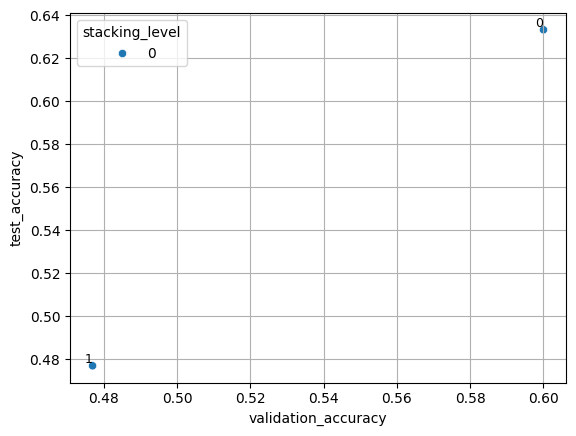

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

df = summary.to_pandas()

ax = sns.scatterplot(data=df, x="validation_accuracy", y="test_accuracy", hue="stacking_level")

for i, row in df.iterrows():
    ax.text(row["validation_accuracy"], row["test_accuracy"], str(row["model_id"]),
            fontsize=9, ha='right', va='bottom')
plt.grid()
plt.show()

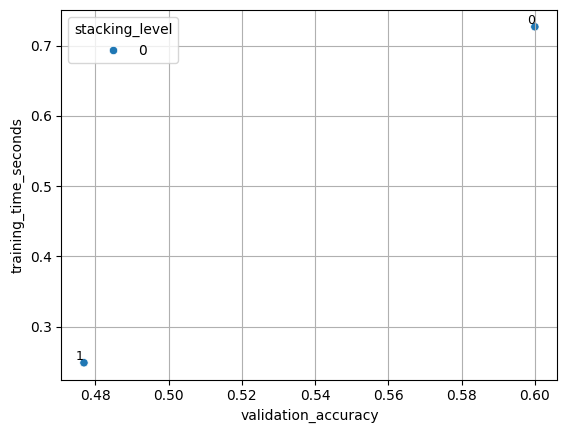

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

df = summary.to_pandas()

ax = sns.scatterplot(data=df, x="validation_accuracy", y="training_time_seconds", hue="stacking_level")

for i, row in df.iterrows():
    ax.text(row["validation_accuracy"], row["training_time_seconds"], str(row["model_id"]),
            fontsize=9, ha='right', va='bottom')
plt.grid()
plt.show()

In [11]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

2025-11-16 12:32:26,591	INFO worker.py:2012 -- Started a local Ray instance.
(make_prediction pid=4119682) 2025-11-16 12:32:32.074182: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
(make_prediction pid=4119682) To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
(make_prediction pid=4119680) 2025-11-16 12:32:32.616121: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations. [repeated 5x across cluster]
(make_prediction pid=4119680) To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags. [repeated 5x across cluster]


Accuracy: 0.6128


In [12]:
from aeon.classification.convolution_based import RocketClassifier, MultiRocketClassifier, MiniRocketClassifier

clf2 = MultiRocketClassifier(n_jobs=-1)
clf2.fit(X_train, y_train)
y_pred2 = clf2.predict(X_test)
accuracy2 = accuracy_score(y_test, y_pred2)
print(f"MultiRocket Accuracy: {accuracy2:.4f}")

MultiRocket Accuracy: 0.8308


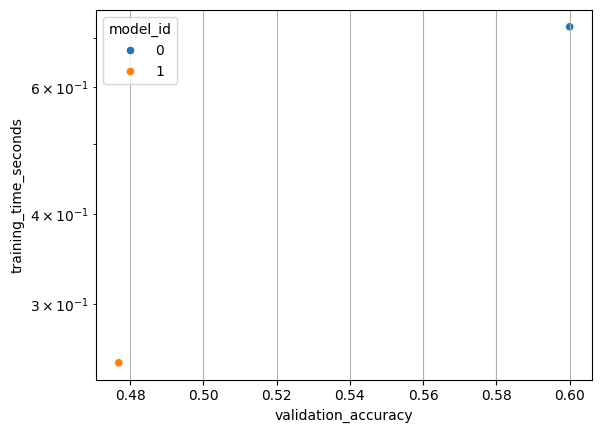

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(
    data=model.summary().to_pandas(), 
    x="validation_accuracy", 
    y="training_time_seconds",
    hue="model_id",
)
plt.grid()
plt.yscale("log")